<a href="https://colab.research.google.com/github/lmaryemoralesnunez/Procesos-Estocasticos/blob/main/TareaProcesosDescomposicionCanonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Descomposicion Canonica
Laura Maryem Morales Nuñez

**Matriz** **y** **diagrama**

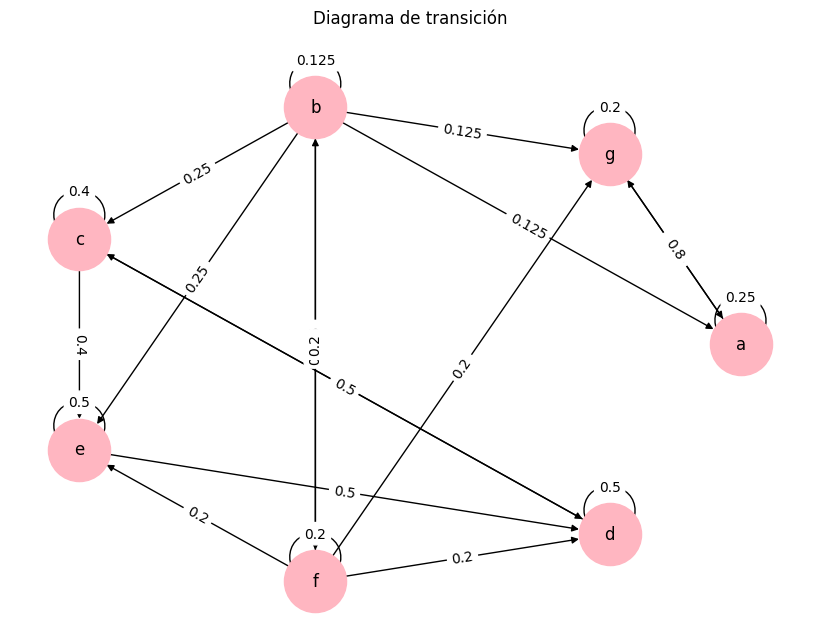

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Matriz P
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

estados = ['a','b','c','d','e','f','g']

# Grafo
G = nx.DiGraph()

for i in range(len(P)):
    for j in range(len(P)):
        if P[i,j] > 0:
            G.add_edge(estados[i], estados[j], weight=P[i,j])

pos = nx.circular_layout(G)
labels = nx.get_edge_attributes(G,'weight')

plt.figure(figsize=(8,6))
nx.draw(G, pos, with_labels=True, node_color='lightpink', node_size=2000)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Diagrama de transición")
plt.show()

**¿Tiene** **distribucion** **limite?**

In [ ]:
import numpy as np

def analizar_limite(P, potencias=[10, 20, 50, 100]):
    for n in potencias:
        Pn = np.linalg.matrix_power(P, n)
        print(f"\nP^{n} =")
        print(np.round(Pn, 3))

analizar_limite(P)


P^10 =
[[0.517 0.    0.    0.    0.    0.    0.483]
 [0.172 0.    0.222 0.267 0.178 0.    0.161]
 [0.    0.    0.333 0.4   0.267 0.    0.   ]
 [0.    0.    0.333 0.4   0.267 0.    0.   ]
 [0.    0.    0.333 0.4   0.267 0.    0.   ]
 [0.172 0.    0.222 0.267 0.178 0.    0.161]
 [0.515 0.    0.    0.    0.    0.    0.485]]

P^20 =
[[0.516 0.    0.    0.    0.    0.    0.484]
 [0.172 0.    0.222 0.267 0.178 0.    0.161]
 [0.    0.    0.333 0.4   0.267 0.    0.   ]
 [0.    0.    0.333 0.4   0.267 0.    0.   ]
 [0.    0.    0.333 0.4   0.267 0.    0.   ]
 [0.172 0.    0.222 0.267 0.178 0.    0.161]
 [0.516 0.    0.    0.    0.    0.    0.484]]

P^50 =
[[0.516 0.    0.    0.    0.    0.    0.484]
 [0.172 0.    0.222 0.267 0.178 0.    0.161]
 [0.    0.    0.333 0.4   0.267 0.    0.   ]
 [0.    0.    0.333 0.4   0.267 0.    0.   ]
 [0.    0.    0.333 0.4   0.267 0.    0.   ]
 [0.172 0.    0.222 0.267 0.178 0.    0.161]
 [0.516 0.    0.    0.    0.    0.    0.484]]

P^100 =
[[0.516 0.    0.   

Al calcular P^n para valores grandes de n, se observa que las filas no convergen a un mismo vector. Por lo tanto, la cadena no posee distribución límite única.

**Descomposicion**  **Canonica**

In [ ]:
# Orden nuevo
orden = [1,5, 0,6, 2,3,4]

P_canonica = P[orden][:,orden]

print("Matriz en forma canónica:")
print(P_canonica)

Matriz en forma canónica:
[[0.125 0.125 0.125 0.125 0.25  0.    0.25 ]
 [0.2   0.2   0.    0.2   0.    0.2   0.2  ]
 [0.    0.    0.25  0.75  0.    0.    0.   ]
 [0.    0.    0.8   0.2   0.    0.    0.   ]
 [0.    0.    0.    0.    0.4   0.2   0.4  ]
 [0.    0.    0.    0.    0.5   0.5   0.   ]
 [0.    0.    0.    0.    0.    0.5   0.5  ]]


**Limite de P^n**

In [ ]:
P_n = np.linalg.matrix_power(P, 100)
print(P_n)

[[5.16129032e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.83870968e-01]
 [1.72043011e-01 5.93420780e-50 2.22222222e-01 2.66666667e-01
  1.77777778e-01 5.93420780e-50 1.61290323e-01]
 [0.00000000e+00 0.00000000e+00 3.33333333e-01 4.00000000e-01
  2.66666667e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.33333333e-01 4.00000000e-01
  2.66666667e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.33333333e-01 4.00000000e-01
  2.66666667e-01 0.00000000e+00 0.00000000e+00]
 [1.72043011e-01 9.49473248e-50 2.22222222e-01 2.66666667e-01
  1.77777778e-01 9.49473248e-50 1.61290323e-01]
 [5.16129032e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.83870968e-01]]


In [ ]:
def descomposicion_canonica(P):
    import networkx as nx

    n = len(P)
    G = nx.DiGraph()

    for i in range(n):
        for j in range(n):
            if P[i,j] > 0:
                G.add_edge(i,j)

    clases = list(nx.strongly_connected_components(G))

    print("Clases de comunicación:")
    for c in clases:
        print(c)

    return clases

In [ ]:
clases = descomposicion_canonica(P)

Clases de comunicación:
{0, 6}
{2, 3, 4}
{1, 5}


La cadena no es irreducible, por lo tanto no tiene distribución límite única. Cada clase cerrada posee su propia distribución estacionaria.